### Импортируем библиотеки

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import gdown
import pandas as pd

Включаем отображение графиков прямо в ноутбуке

In [3]:
%matplotlib inline

## Загружаем исходный файл
`!gdown` у меня недоступен как системная команда в оболочке zsh, которую  юпитер ноутбук использует для выполнения команд с !. 
Вместо этого используем Python API библиотеку gdown напрямую через `gdown.download()`, так как он работает в том же Python-окружении, что и весь ноутбук и не зависит от системных путей и настроек оболочки

In [4]:
file_id = "1OKwRSPXs212Mzttg4D0GFFkiap-GztP_"
url = f"https://drive.google.com/uc?id={file_id}"
output = "Wiki-Vote.txt"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1OKwRSPXs212Mzttg4D0GFFkiap-GztP_
To: /Users/user/HSE/Network Models/HW/Wiki-Vote.txt
100%|██████████| 1.10M/1.10M [00:00<00:00, 6.65MB/s]


'Wiki-Vote.txt'

### Выводим основные свойства графа:
- количество узлов
- количество ребер
- плотность графа
- взаимность связей

In [4]:
G = nx.read_edgelist('Wiki-Vote.txt',create_using=nx.DiGraph())

print('Nodes:',G.number_of_nodes())
print('Edges:',G.number_of_edges())
print('Density:',nx.density(G))
print('Reciprocity:', nx.reciprocity(G))

Nodes: 7115
Edges: 103689
Density: 0.0020485375110809584
Reciprocity: 0.0564572905515532


## 1. Структурно-сетевые свойства направленной сети

### 1)  Распределение степеней (2 балла)
Постройте распределение степеней (in, out). Какой статистике подчиняются распределения?

Вычисляем степени узлов и преобразуем их в списки для дальнейшего анализа:
- `in-degree` - сколько человек проголосовало за данного участника
- `out-degree` - за скольких человек проголосовал данный участник

In [5]:
in_degrees = dict(G.in_degree())    # входящие степени 
out_degrees = dict(G.out_degree())  # исходящие степени

in_deg_values = list(in_degrees.values())
out_deg_values = list(out_degrees.values())

Вычисляем основные статистики

In [52]:
print(f"Входящие степени:")
print(f"• минимум - {min(in_deg_values)}")
print(f"• максимум - {max(in_deg_values)}")
print(f"• среднее - {np.mean(in_deg_values):.2f}")
print(f"• медиана - {np.median(in_deg_values)}")

print(f"\nИсходящие степени:")
print(f"• минимум - {min(out_deg_values)}")
print(f"• максимум - {max(out_deg_values)}")
print(f"• среднее - {np.mean(out_deg_values):.2f}")
print(f"• медиана - {np.median(out_deg_values)}")

Входящие степени:
• минимум - 0
• максимум - 457
• среднее - 14.57
• медиана - 0.0

Исходящие степени:
• минимум - 0
• максимум - 893
• среднее - 14.57
• медиана - 2.0


Строим гистограммы распределений степеней, используем логарифмическую шкалу

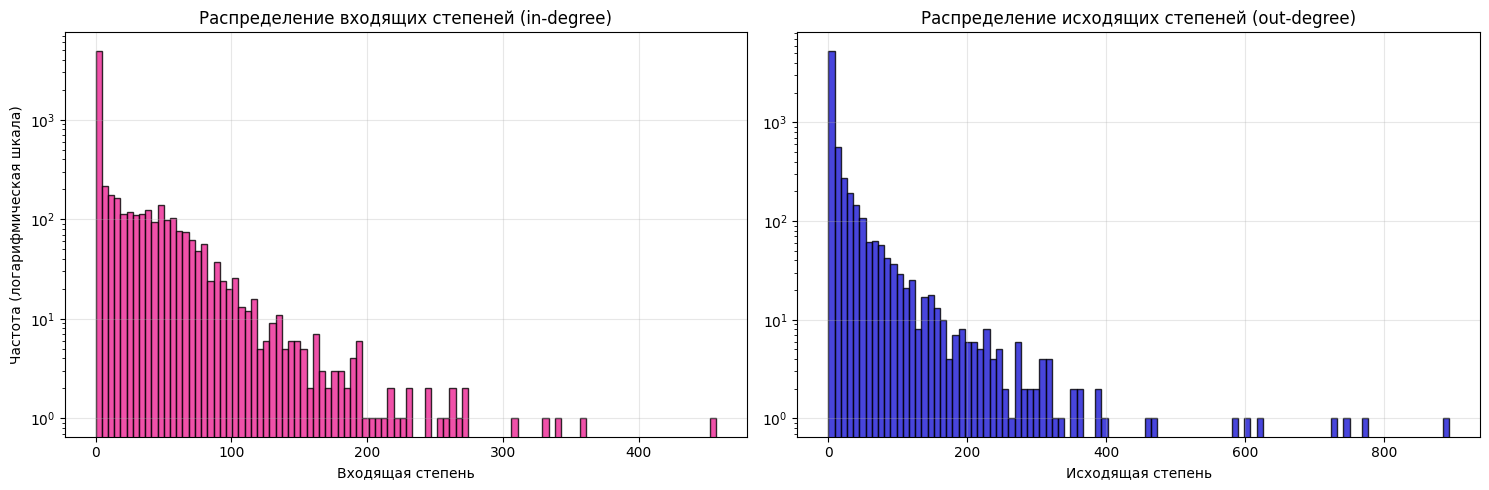

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Входящие степени
axes[0].hist(in_deg_values, bins=100, edgecolor='black', color='#ed2694', alpha=0.8, log=True)
axes[0].set_title('Распределение входящих степеней (in-degree)')
axes[0].set_xlabel('Входящая степень')
axes[0].set_ylabel('Частота (логарифмическая шкала)')
axes[0].grid(True, alpha=0.3)

# Исходящие степени
axes[1].hist(out_deg_values, bins=100, edgecolor='black', color='#1a17d4', alpha=0.8, log=True)
axes[1].set_title('Распределение исходящих степеней (out-degree)')
axes[1].set_xlabel('Исходящая степень')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Выводы по распределению степеней:
Wiki-Vote - сеть с неравномерным распределением активности:
- часть пользователей часто номинируется (высокая in-degree)
- часть пользователей активно голосует (высокая out-degree)

Оба распределения имеют 'тяжелый хвост', что характерно для сетей, подчиняющихся степенному закону. В логарифмической шкале гистограммы показывают линейный тренд. Большинство узлов имеют малую степень, но есть несколько узлов с очень высокой степенью (хабы). 

### 2)  Ассортативность (1 балл)
Вычислите ассортативность, результат представьте в виде матрицы, всего 4 значения для разных комбинаций in/out степеней.

Вычисляем ассортативность для разных комбинаций степеней:
- `in→in` - связь между входящими степенями соседних узлов
- `in→out` - связь входящей степени узла с исходящей степенью соседа
- `out→in` - связь исходящей степени узла с входящей степенью соседа
- `out→out` - связь между исходящими степенями соседних узлов

In [8]:
assort_in_in = nx.degree_assortativity_coefficient(G, x='in', y='in')
assort_in_out = nx.degree_assortativity_coefficient(G, x='in', y='out')
assort_out_in = nx.degree_assortativity_coefficient(G, x='out', y='in')
assort_out_out = nx.degree_assortativity_coefficient(G, x='out', y='out')

Строим матрицу ассортативности. Ассортативность показывает, связаны ли узлы с похожими степенями

Интерпретация значений:
- _положительные значения_ - узлы связываются с похожими узлами (ассортативность)
- _отрицательные значения_ - узлы связываются с непохожими узлами (диссассортативность)
- _близкие к нулю значения_ - случайные связи

In [9]:
print("in→in    in→out")
print(f"{assort_in_in:.4f}    {assort_in_out:.4f}")
print("\nout→in   out→out")
print(f"{assort_out_in:.4f}    {assort_out_out:.4f}")

in→in    in→out
0.0051    0.0071

out→in   out→out
-0.0832    -0.0189


### Выводы по матрице ассортативности: 
Коэффициенты ассортативности по различным типам степеней близки к нулю и в ряде случаев имеют отрицательный знак, что указывает на слабую дисассортативность направленной сети. Это означает, что активные пользователи чаще взаимодействуют с менее активными или более популярными участниками.

- `in→in` - слабоположительная ассортативность

Положительное, но очень близкое к нулю значение. Узлы со схожим числом входящих голосов имеют статистически незначимую тенденцию связываться друг с другом, то есть популярность (in-degree) практически не влияет на выбор того, за кого голосовать. Пользователи, которые получили примерно одинаковое количество голосов "за", с незначительной тенденцией голосуют друг за друга.


- `in→out` - слабоположительная ассортативность

Тоже положительное и близкое к нулю значение. Говорит о наличии связи между популярностью узла и активностью его соседей в голосовании: популярные пользователи привлекают активных голосующих. Если у пользователя много голосов "за", то те, кто за него голосовал, тоже склонны активно голосовать за других.


- `out→in` - умеренная диссассортативность

Самое большое по модулю значение в матрице и отрицательное (диссассортативность). Свидетельствует о том, что активные голосующие (большой out-degree) склонны голосовать за непопулярных пользователей. То есть пользователи, которые много голосуют за других, не следуют за всеми и часто голосуют за менее популярных кандидатов. 


- `out→out` - слабая диссассортативность

Маленькое отрицательное значение. Активные голосующие имеют слабую тенденцию не связываться с другими активными голосующими. Пользователи, которые много голосуют, редко голосуют друг за друга.

### 3)  Связность (1 балл)
Является ли сеть сильно/слабо связанной? Постройте распределение размеров сильно связанных компонент. Сколько вершин входит в компоненту наибольшего размера?

Характеристики связи компонент (группы связанных между собой узлов): 
- `сильно связные компоненты (SCC)` - можно добраться от любого узла к любому другому по направленным ребрам
- `слабо связные компоненты (WCC)` - можно добраться от любого узла к любому другому, игнорируя направление ребер

In [10]:
strongly_connected_components = list(nx.strongly_connected_components(G))
weakly_connected_components = list(nx.weakly_connected_components(G))

print(f"Количество сильно связных компонент (SCC): {len(strongly_connected_components)}")
print(f"Количество слабо связных компонент (WCC): {len(weakly_connected_components)}")

Количество сильно связных компонент (SCC): 5816
Количество слабо связных компонент (WCC): 24


Определяем самую большую сильно связную компоненту

In [11]:
largest_scc = max(strongly_connected_components, key=len)
largest_scc_size = len(largest_scc)
print(f"Размер самой большой сильно связной компоненты: {largest_scc_size} узлов")

Размер самой большой сильно связной компоненты: 1300 узлов


Строим гистограмму размеров сильно связных компонент

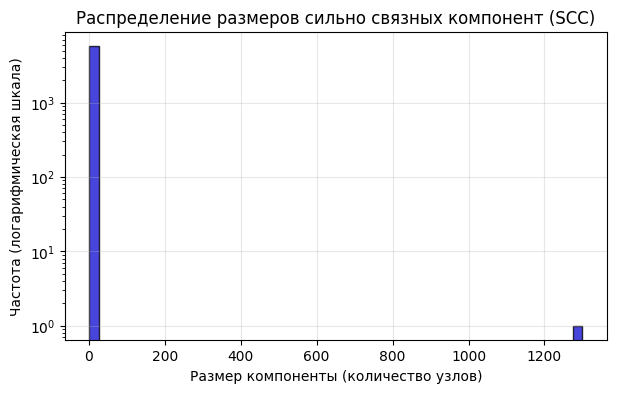

In [12]:
scc_sizes = [len(component) for component in strongly_connected_components]

plt.figure(figsize=(7, 4))
plt.hist(scc_sizes, bins=50, edgecolor='black', color='#1a17d4', alpha=0.8, log=True)
plt.title('Распределение размеров сильно связных компонент (SCC)')
plt.xlabel('Размер компоненты (количество узлов)')
plt.ylabel('Частота (логарифмическая шкала)')
plt.grid(True, alpha=0.3)
plt.show()

### Выводы по связанности сети:
Сеть не является сильно связной, но содержит большую сильно связную компоненту. Это означает, что между большинством вершин возможен двусторонний обмен информацией, но глобально сеть остается фрагментированной.

In [13]:
if len(strongly_connected_components) == 1:
    print("Сеть является сильно связной (все узлы достижимы друг из друга по направленным ребрам)")
else:
    print("Сеть не является сильно связной")
    
if len(weakly_connected_components) == 1:
    print("Сеть является слабо связной (если игнорировать направление ребер)")
else:
    print("Сеть не является слабо связной")

Сеть не является сильно связной
Сеть не является слабо связной


### 4) Кратчайшие пути (1 балл)
Определите среднюю длину кратчайшего пути в наибольшей сильно связной компоненте.

Создаем подграф самой большой сильно связной компоненты (так как внутри нее между любыми вершинами существует путь в обоих направлениях) и вычисляем среднюю длину кратчайшего пути -  сколько в среднем шагов нужно, чтобы добраться от одного узла к другому

In [14]:
largest_scc_graph = G.subgraph(largest_scc).copy()

if len(largest_scc_graph) < 5000:
    avg_path_length = nx.average_shortest_path_length(largest_scc_graph)
    print(f"Средняя длина кратчайшего пути (точный расчет): {avg_path_length:.4f}")
    
# Для больших графов используем аппроксимацию
else:
    # Выбираем случайную выборку узлов
    sample_size = min(100, len(largest_scc_graph))
    sample_nodes = np.random.choice(list(largest_scc_graph.nodes()), sample_size, replace=False)
        
    path_lengths = []
    for i, source in enumerate(sample_nodes):
    # Вычисляем кратчайшие пути от source до всех достижимых узлов
        lengths = nx.single_source_shortest_path_length(largest_scc_graph, source)
        path_lengths.extend(lengths.values())
        
    avg_path_length = np.mean(path_lengths)
    print(f"Средняя длина кратчайшего пути (аппроксимация по {sample_size} узлам): {avg_path_length:.4f}")

Средняя длина кратчайшего пути (точный расчет): 2.8793


### Выводы по кратчайшему пути:
Малая средняя длина кратчайшего пути в самой большой сильно связной компоненте объясняется наличием высокостепенных узлов, которые соединяют значительную часть сети

## Загружаем исходный файл
Повторяем аналогично через `gdown.download()`

In [15]:
file_id_spreading = "1JziO7FuzyDWeUOGUNusHSPdppFodJ670"
url = f"https://drive.google.com/uc?id={file_id_spreading}"
output = "spreading_data_wiki-Vote.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1JziO7FuzyDWeUOGUNusHSPdppFodJ670
To: /Users/user/HSE/Network Models/spreading_data_wiki-Vote.csv
100%|██████████| 187k/187k [00:02<00:00, 91.9kB/s]


'spreading_data_wiki-Vote.csv'

Записываем данные в дата-фрейм и выводим первые 5 строк таблицы

In [16]:
df = pd.read_csv('spreading_data_wiki-Vote.csv')
df.head()

,node,spreading ability
0,30,0.277864
1,1412,0.000141
2,3352,0.280253
3,5254,0.278426
4,5543,0.274209


## Предварительная обработка данных
Для начала проверим, что количество узлов графа и данных соотвествуют друг другу

In [17]:
print(f"Узлов в графе: {len(G.nodes())}")
print(f"Записей в данных о spreading ability: {len(df)}")

Узлов в графе: 7115
Записей в данных о spreading ability: 7115


Проверим тип узлов в графе и данных: в графе узлы хранятся как строки, а в данных - как числа

In [18]:
sample_node = list(G.nodes())[0]
print(f"Тип узла в графе: {type(sample_node)}")
print(f"Тип узла в данных: {type(df['node'].iloc[0])}")

Тип узла в графе: <class 'str'>
Тип узла в данных: <class 'numpy.int64'>


Приведем узлы графа к числовому типу, как в данных

In [19]:
G_int = nx.DiGraph()
for u, v in G.edges():
    G_int.add_edge(int(u), int(v))

Проверяем соответствие узлов - узлы между графом и данными не пересекаются

In [20]:
nodes_in_graph = set(G.nodes())
nodes_in_data = set(df['node'])
common_nodes = nodes_in_graph.intersection(nodes_in_data)

print(f"\nУзлы в графе: {len(nodes_in_graph)}")
print(f"Узлы в данных: {len(nodes_in_data)}")
print(f"Общие узлы: {len(common_nodes)}")


Узлы в графе: 7115
Узлы в данных: 7115
Общие узлы: 0


## 2. Центральности и прогнозирование динамической влиятельности в направленной сети

### 1)  Классы (1 балл)
 Разделите вершины на два класса по значению spreading ability: "хорошо " распространяют эпидемию и "плохо".

Создаем словарь spreading ability для узлов графа

In [21]:
spreading_dict = dict(zip(df['node'], df['spreading ability']))

Анализируем распределение spreading ability для выбора порога

In [22]:
df['spreading ability'].describe()

count    7115.000000
mean        0.084281
std         0.128044
min         0.000141
25%         0.000141
50%         0.000141
75%         0.276739
max         0.287280
Name: spreading ability, dtype: float64

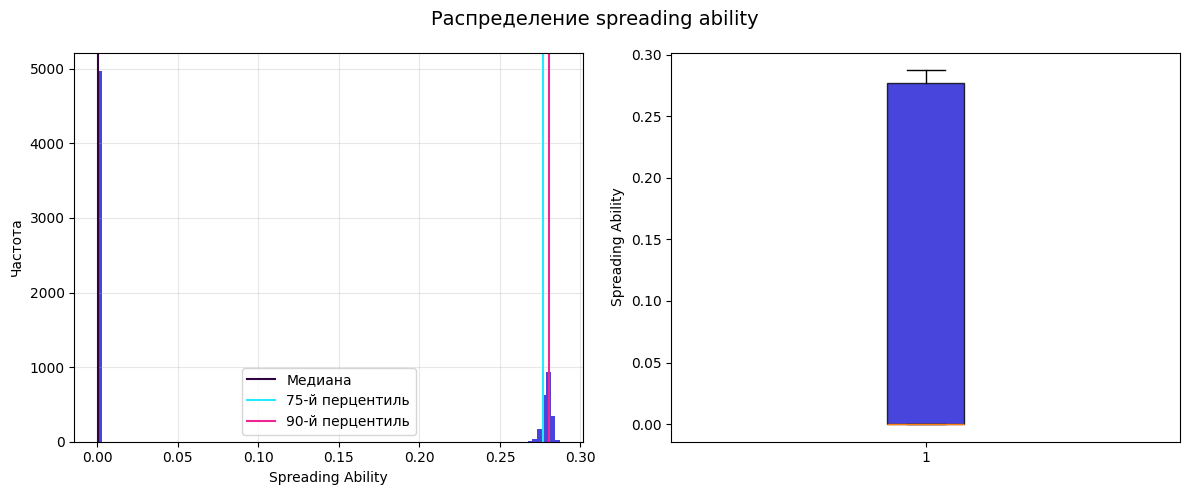

In [23]:
plt.figure(figsize=(12, 5))
plt.suptitle('Распределение spreading ability', fontsize=14)

# Гистограмма с квантилями
plt.subplot(1, 2, 1)
df['spreading ability'].hist(bins=100, alpha=0.8, color='#1a17d4')
plt.axvline(df['spreading ability'].quantile(0.5), color='#2f0440', linestyle='-', label='Медиана')
plt.axvline(df['spreading ability'].quantile(0.75), color='#23eafc', linestyle='-', label='75-й перцентиль')
plt.axvline(df['spreading ability'].quantile(0.9), color='#ed2694', linestyle='-', label='90-й перцентиль')
plt.xlabel('Spreading Ability')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

# Ящик с усами
plt.subplot(1, 2, 2)
box_plot = plt.boxplot(df['spreading ability'], patch_artist=True)
box_plot['boxes'][0].set_facecolor('#1a17d4')
box_plot['boxes'][0].set_alpha(0.8)
plt.ylabel('Spreading Ability')

plt.tight_layout()
plt.show()

### Выводы по распределению spreading ability:
Высокая spreading ability характерна для вершин, которые находятся в наибольшей сильно связной компоненте
и обладают выгодным направленным положением в сети. При этом высокая входящая степень сама по себе не гарантирует высокой способности к распространению

Используем медиану как порог для балансировки классов. Разделяем узлы на два класса:
- `1` - "хорошо" распространяют (выше порога) - заражают наибольшее число других вершин за фиксированное время
- `0` - "плохо" распространяют (ниже или равно порогу) - минимально влияют

In [24]:
threshold = df['spreading ability'].median()
print(f"\nПорог для разделения на классы (медиана): {threshold:.6f}")
df['class'] = (df['spreading ability'] > threshold).astype(int)


Порог для разделения на классы (медиана): 0.000141


Выводим статистику по классам

In [53]:
class_counts = df['class'].value_counts()

print(f"Класс 0 (плохо распространяют): {class_counts.get(0, 0)} узлов ({class_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"Класс 1 (хорошо распространяют): {class_counts.get(1, 0)} узлов ({class_counts.get(1, 0)/len(df)*100:.1f}%)")


Класс 0 (плохо распространяют): 4262 узлов (59.9%)
Класс 1 (хорошо распространяют): 2853 узлов (40.1%)


### 2)  AUC-ROC (2 балла)
Для выбранных метрик центральности (2-3 разные меры) постройте AUC-ROC кривую и вычислите соответсвующую площадь.

In [26]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler

Вычисляем метрики центральности:
- `PageRank` - мера важности вершины в направленной сети, основанная на рекурсивном принципе (вершина считается важной, если на нее указывают другие важные вершины)
- `In-Degree Centrality` - количество входящих ребер в вершину, описывающее степень ее популярности в направленной сети
- `Betweenness Centrality` - доля кратчайших путей в сети, проходящих через данную вершину (роль вершины как посредника между другими вершинами)
- `Degree Centrality` - нормированное количество ребер, инцидентных вершине (в направленных сетях используется как агрегированная характеристика, учитывающая входящие и исходящие связи)

In [27]:
# PageRank
pagerank_dict = nx.pagerank(G, alpha=0.85)
pagerank_str_keys = {str(k): v for k, v in pagerank_dict.items()}
df['pagerank'] = df['node'].astype(str).map(pagerank_str_keys)
df['pagerank'] = df['pagerank'].fillna(0)
print(f"Метрика PageRank вычислена для {len(pagerank_dict)} узлов")
print(f"Минимум = {df['pagerank'].min():.4f}, Максимум = {df['pagerank'].max():.4f}")

# In-Degree Centrality 
in_degree_dict = {str(node): G.in_degree(node) for node in G.nodes()}
df['in-degree'] = df['node'].astype(str).map(in_degree_dict)
df['in-degree'] = df['in-degree'].fillna(0)
print(f"\nМетрика In-Degree Centrality вычислена для {len(in_degree_dict)} узлов")
print(f"Минимум = {df['in-degree'].min():.0f}, Максимум = {df['in-degree'].max():.0f}")


# Betweenness Centrality
betweenness_dict = nx.betweenness_centrality(G, k=100)  # k - количество узлов для выборки
betweenness_str_keys = {str(k): v for k, v in betweenness_dict.items()}
df['betweenness'] = df['node'].astype(str).map(betweenness_str_keys)
df['betweenness'] = df['betweenness'].fillna(0)
print(f"\nМетрика Betweenness Centrality вычислена для {len(betweenness_dict)} узлов")
print(f"Минимум = {df['betweenness'].min():.4f}, Максимум = {df['betweenness'].max():.4f}")

# Degree Centrality
degree_dict = {str(node): G.degree(node) for node in G.nodes()}
df['degree'] = df['node'].astype(str).map(degree_dict)
df['degree'] = df['degree'].fillna(0)
print(f"\nМетрика Degree Centrality вычислена для {len(degree_dict)} узлов")
print(f"Минимум = {df['degree'].min():.0f}, Максимум = {df['degree'].max():.0f}")

Метрика PageRank вычислена для 7115 узлов
Минимум = 0.0001, Максимум = 0.0046

Метрика In-Degree Centrality вычислена для 7115 узлов
Минимум = 0, Максимум = 457

Метрика Betweenness Centrality вычислена для 7115 узлов
Минимум = 0.0000, Максимум = 0.0201

Метрика Degree Centrality вычислена для 7115 узлов
Минимум = 1, Максимум = 1167


### Подготовка данных
Оставляем только узлы, для которых есть все метрики

In [28]:
available_metrics = []
for metric in ['pagerank', 'in-degree', 'betweenness', 'degree']:
    if metric in df.columns and not df[metric].isnull().all() and df[metric].std() > 0:
        available_metrics.append(metric)

print(f"\nДоступные метрики центральности: {available_metrics}")


Доступные метрики центральности: ['pagerank', 'in-degree', 'betweenness', 'degree']


In [29]:
df_clean = df.dropna(subset=available_metrics + ['class']).copy()

print(f"Узлов для анализа: {len(df_clean)}")
print(f"Класс 0: {(df_clean['class'] == 0).sum()} узлов")
print(f"Класс 1: {(df_clean['class'] == 1).sum()} узлов")

Узлов для анализа: 7115
Класс 0: 4262 узлов
Класс 1: 2853 узлов


Нормализуем метрики для сравнения

In [30]:
scaler = StandardScaler()
for metric in available_metrics:
    df_clean[f'{metric}_norm'] = scaler.fit_transform(df_clean[[metric]])

Строим AUC-ROC кривую и вычисляем площадь под ней

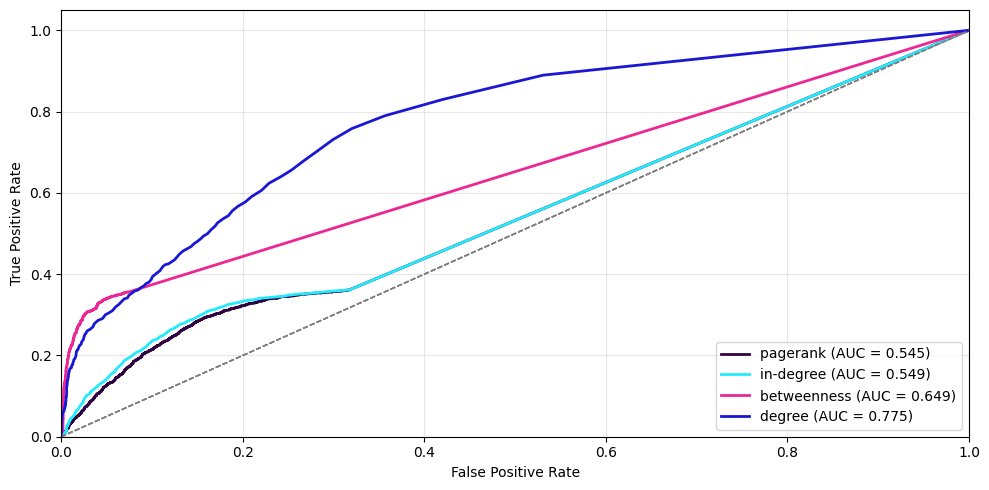

In [31]:
def plot_roc_curve(y_true, y_scores, metric_name, ax, color):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # AUC-ROC кривая
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{metric_name} (AUC = {roc_auc:.3f})')
    
    # Диагональ (случайный классификатор)
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    
    return roc_auc

# Строим AUC-ROC кривую для каждой метрики
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2f0440', '#23eafc', '#ed2694', '#1a17d4']
auc_scores = {}

for i, metric in enumerate(available_metrics):
    if i < len(colors):
        color = colors[i]
    else:
        color = 'gray'
    
    auc_score = plot_roc_curve(
        df_clean['class'], 
        df_clean[f'{metric}_norm'], 
        metric, 
        ax, 
        color
    )
    auc_scores[metric] = auc_score

plt.tight_layout()
plt.show()

### Выводы по AUC-ROC кривой: 
Значение AUC (площади под кривой) показывает вероятность того, что вершина с большей центральностью окажется более влиятельной в динамической модели распространения. Чем ближе значение AUC к 1, тем лучше метрика предсказывает spreading ability. Значения AUC выше 0.5 показывают, что выбранные центральности предсказывают spreading ability лучше случайного выбора, однако не обеспечивают идеального разделения влиятельных и невлиятельных вершин.

- метрика `pagerank` - слабая предсказательная способность (0.5 < AUC < 0.6)
- метрика `in-degree` - слабая предсказательная способность (0.5 < AUC < 0.6)
- метрика `betweenness` - умеренная предсказательная способность (0.6 < AUC < 0.7)
- метрика `degree` - хорошая предсказательная способность (AUC > 0.7)

### 3) Гибридная центральность (3 балла)
Для  гибридной центральности  постройте зависимость площади под AUC-ROC кривой от параметра  σ . Каков оптимальный параметр гибридной центральности?

Гибридная центральность: H = σ * C1 + (1 - σ) * C2
- `C1` и `C2` - две разные метрики центральности
- `σ` - параметр смешивания (от 0 до 1)

Выбираем две лучшие метрики по значению AUC для гибридной центральности

In [32]:
if len(available_metrics) >= 2:
    sorted_metrics = sorted(auc_scores.items(), key=lambda x: x[1], reverse=True)
    
    best_metric1 = sorted_metrics[0][0]  # первая лучшая метрика
    best_metric2 = sorted_metrics[1][0]  # вторая лучшая метрика
    
    print(f"Метрики для гибридной центральности:")
    print(f"C1 - {best_metric1} (AUC = {auc_scores[best_metric1]:.4f})")
    print(f"C2 - {best_metric2} (AUC = {auc_scores[best_metric2]:.4f})")
    
    # Используем нормализованные значения метрик
    C1_values = df_clean[f'{best_metric1}_norm'].values
    C2_values = df_clean[f'{best_metric2}_norm'].values
    y_true = df_clean['class'].values

Метрики для гибридной центральности:
C1 - degree (AUC = 0.7751)
C2 - betweenness (AUC = 0.6495)


Считаем значение AUC для разных значений σ

In [ ]:
# Параметры σ для исследования (от 0 до 1)
sigma_values = np.linspace(0, 1, 21) 
hybrid_auc_scores = []

for sigma in sigma_values:
    # Вычисляем гибридную центральность
    H = sigma * C1_values + (1 - sigma) * C2_values
    
    # Вычисляем AUC для гибридной центральности
    auc_score = roc_auc_score(y_true, H)
    hybrid_auc_scores.append(auc_score)

# Находим оптимальное значение σ (максимизирует AUC)
optimal_idx = np.argmax(hybrid_auc_scores)
optimal_sigma = sigma_values[optimal_idx]
optimal_auc = hybrid_auc_scores[optimal_idx]

Визуализируем зависимость AUC от параметра σ

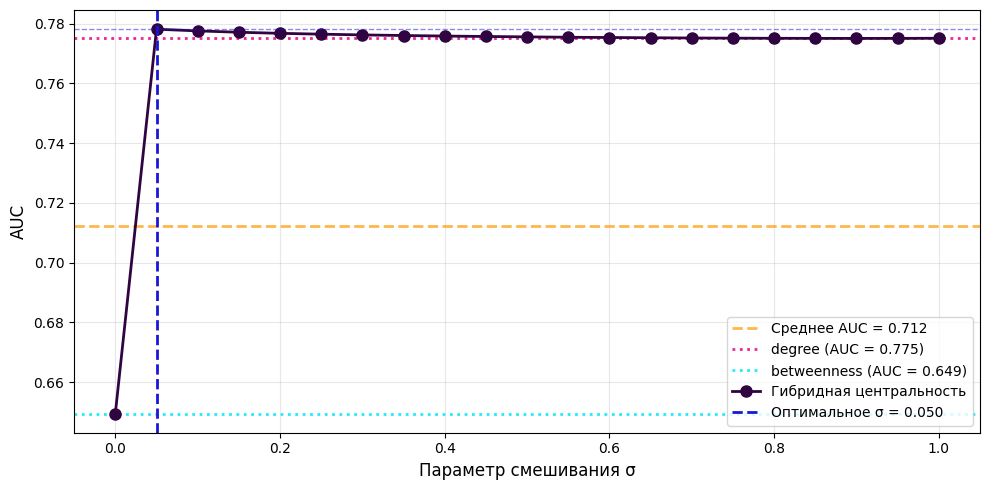

In [34]:
plt.figure(figsize=(10, 5))

colors = ['#ed2694', '#23eafc', '#2f0440', '#1a17d4', '#ff9900', '#800080']

# Среднее значение AUC
mean_individual_auc = (auc_scores[best_metric1] + auc_scores[best_metric2]) / 2
plt.axhline(y=mean_individual_auc, color=colors[4], linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Среднее AUC = {mean_individual_auc:.3f}')

# AUC отдельных метрик
plt.axhline(y=auc_scores[best_metric1], color=colors[0], linestyle=':', 
            linewidth=2, label=f'{best_metric1} (AUC = {auc_scores[best_metric1]:.3f})')
plt.axhline(y=auc_scores[best_metric2], color=colors[1], linestyle=':', 
            linewidth=2, label=f'{best_metric2} (AUC = {auc_scores[best_metric2]:.3f})')

# Гибридная центральность
plt.plot(sigma_values, hybrid_auc_scores, color=colors[2], marker='o', 
         linewidth=2, markersize=8, label='Гибридная центральность')

# Оптимальное значение σ
plt.axvline(x=optimal_sigma, color=colors[3], linestyle='--', 
            linewidth=2, label=f'Оптимальное σ = {optimal_sigma:.3f}')
plt.axhline(y=optimal_auc, color=colors[3], linestyle='--', 
            linewidth=1, alpha=0.5)

plt.xlabel('Параметр смешивания σ', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([-0.05, 1.05])

plt.legend(loc='best')

plt.tight_layout()
plt.show()

Выводим результаты и сравниваем значение оптимального AUC cо значением AUC отдельных метрик. Определяем влияние гибридной центральности на предсказание

In [35]:
print(f"Оптимальный параметр σ: {optimal_sigma:.3f}")
print(f"Максимальный AUC гибридной центральности: {optimal_auc:.4f}")

# Сравнение с отдельными метриками
improvement_vs_best = optimal_auc - auc_scores[best_metric1]
improvement_vs_worst = optimal_auc - auc_scores[best_metric2]
improvement_vs_mean = optimal_auc - mean_individual_auc

print(f"\nУлучшение относительно {best_metric1}: {improvement_vs_best:+.4f}")
print(f"Улучшение относительно {best_metric2}: {improvement_vs_worst:+.4f}")
print(f"Улучшение относительно среднего: {improvement_vs_mean:+.4f}")

# Вывод
if improvement_vs_best > 0.01:
    conclusion = "Гибридная центральность значительно улучшает предсказание"
elif improvement_vs_best > 0:
    conclusion = "Гибридная центральность незначительно улучшает предсказание"
elif abs(improvement_vs_best) < 0.001:
    conclusion = "Гибридная центральность дает такой же результат, как лучшая метрика"
else:
    conclusion = "Лучше использовать отдельную метрику"

print(f"\n{conclusion}")

Оптимальный параметр σ: 0.050
Максимальный AUC гибридной центральности: 0.7781

Улучшение относительно degree: +0.0030
Улучшение относительно betweenness: +0.1286
Улучшение относительно среднего: +0.0658

Гибридная центральность незначительно улучшает предсказание


Выводим значения AUC для разных значений параметра σ

In [36]:
print(f"{'σ':<8} {'AUC':<10} {'Примечание':<25}")
print("-"*40)

for i, (sigma, auc_val) in enumerate(zip(sigma_values, hybrid_auc_scores)):
    note = ""
    if i == 0:
        note = f"Только {best_metric2}"
    elif i == len(sigma_values) - 1:
        note = f"Только {best_metric1}"
    elif sigma == 0.5:
        note = "Равное смешивание"
    elif sigma == optimal_sigma:
        note = "ОПТИМАЛЬНО"
    
    print(f"{sigma:<8.3f} {auc_val:<10.4f} {note:<25}")

σ        AUC        Примечание               
----------------------------------------
0.000    0.6495     Только betweenness       
0.050    0.7781     ОПТИМАЛЬНО               
0.100    0.7775                              
0.150    0.7771                              
0.200    0.7767                              
0.250    0.7765                              
0.300    0.7762                              
0.350    0.7760                              
0.400    0.7758                              
0.450    0.7757                              
0.500    0.7755     Равное смешивание        
0.550    0.7754                              
0.600    0.7753                              
0.650    0.7753                              
0.700    0.7752                              
0.750    0.7751                              
0.800    0.7751                              
0.850    0.7750                              
0.900    0.7750                              
0.950    0.7750                        

### Выводы по оптимальному значению параметра σ:
- оптимальное значение σ равно 0.05 (доля метрики degree равна 5.0%, а доля метрики betweenness - 95.0%)
- метрика betweenness является доминирующей в гибридной центральности
- AUC при оптимальном значений параметра σ равен 0.7782
- гибридная центральность улучшает предсказание на 0.0031 (рекомендуется ее использовать)

Для большей наглядности сравним AUC-ROC кривые отдельных метрик и оптимальной гибридной центральности

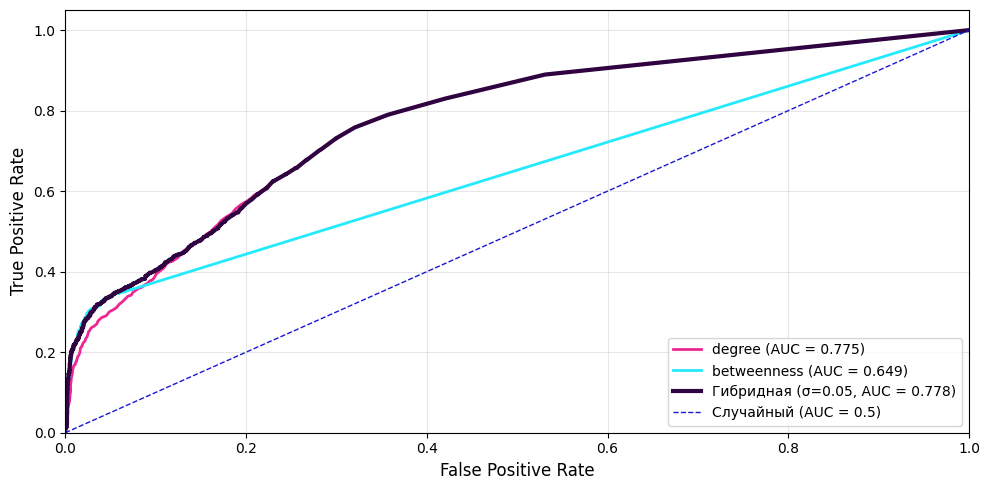

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#ed2694', '#23eafc', '#2f0440', '#1a17d4'] 

# AUC-ROC-кривые для отдельных метрик
for i, metric in enumerate([best_metric1, best_metric2]):
    fpr, tpr, _ = roc_curve(y_true, df_clean[f'{metric}_norm'])
    auc_val = auc_scores[metric]
    ax.plot(fpr, tpr, color=colors[i], lw=2, 
            label=f'{metric} (AUC = {auc_val:.3f})')

# AUC-ROC-кривая для оптимальной гибридной центральности
H_optimal = optimal_sigma * C1_values + (1 - optimal_sigma) * C2_values
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_true, H_optimal)
auc_hybrid = auc(fpr_hybrid, tpr_hybrid)
ax.plot(fpr_hybrid, tpr_hybrid, color=colors[2], lw=3, 
        label=f'Гибридная (σ={optimal_sigma:.2f}, AUC = {auc_hybrid:.3f})')

# Диагональ (случайный классификатор)
ax.plot([0, 1], [0, 1], color=colors[3], lw=1, linestyle='--', 
        label='Случайный (AUC = 0.5)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Моделирование направленной сети с заданным значением взаимности (доли двунаправленных связей)

### 1) Генератор (3 балла)
Напишите генератор случайного направленного графа Эрдеша-Реньи с заданной вероятностью связи  𝑝  и долей двунаправленных связей  𝑟 .

In [38]:
from itertools import combinations

Создаем генератор направленного графа Эрдеша-Реньи. Параметры:
- `n` - количество узлов
- `p` - вероятность существования ребра (между любой парой узлов)
- `r` - доля двунаправленных связей (от 0 до 1)
- `seed` - для воспроизводимости

In [39]:
def generate_directed_erdos_renyi(n, p, r, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    # Создаем пустой направленный граф
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    
    # Список всех возможных пар узлов
    nodes = list(range(n))
    all_pairs = list(combinations(nodes, 2))
    
    # Проходим по всем парам узлов
    for u, v in all_pairs:
        # Генерируем случайное число для определения наличия связи
        rand = np.random.random()
        
        if rand < p:
            # Определяем тип связи в зависимости от r
            rand_type = np.random.random()
            
            if rand_type < r:
                # Двунаправленная связь (u->v и v->u)
                G.add_edge(u, v)
                G.add_edge(v, u)
            else:
                # Однонаправленная связь - выбираем случайное направление
                if np.random.random() < 0.5:
                    G.add_edge(u, v)
                else:
                    G.add_edge(v, u)
    
    return G

Проверяем работу генератора на примере

In [40]:
test_G = generate_directed_erdos_renyi(n=10, p=0.3, r=0.5, seed=42)
print(f"Сгенерирован граф с {test_G.number_of_nodes()} узлами и {test_G.number_of_edges()} ребрами")

# Вычисляем долю двунаправленных связей
def calculate_reciprocity(G):
    if G.number_of_edges() == 0:
        return 0
    
    reciprocal_edges = 0
    for u, v in G.edges():
        if G.has_edge(v, u):
            reciprocal_edges += 0.5  # учитываем каждую пару один раз
    
    return reciprocal_edges * 2 / G.number_of_edges()  # умножаем на 2, тк каждая взаимная связь дает 2 ребра

actual_r = calculate_reciprocity(test_G)
print(f"Запрошенная доля взаимных связей: 0.5")
print(f"Фактическая доля взаимных связей: {actual_r:.3f}")

Сгенерирован граф с 10 узлами и 28 ребрами
Запрошенная доля взаимных связей: 0.5
Фактическая доля взаимных связей: 0.571


### 2) Пример сети (1 балла)
Для нескольких выбранных пар  (𝑝,𝑟)  постройте распределение степеней, вычислите транзитивность.

Выбираем несколько пар параметров (𝑝,𝑟)

In [41]:
param_pairs = [
    (0.1, 0.2),   # низкая плотность, низкая взаимность
    (0.3, 0.5),   # средняя плотность, средняя взаимность
    (0.5, 0.8),   # высокая плотность, высокая взаимность
]

n_nodes = 100  # количество узлов в тестовых графах
graphs = []

Генерируем графы и анализируем их. Транзитивность (коэффициент кластеризации) показывает вероятность того, что два соседа узла соединены между собой. Чем выше транзитивность, тем более 'кластеризована' сеть. В случайных графах транзитивность примерно равна плотности графа.

In [42]:
for idx, (p, r) in enumerate(param_pairs):
    print(f"\nПАРАМЕТРЫ: p = {p}, r = {r}")
    
    # Генерируем граф
    G = generate_directed_erdos_renyi(n=n_nodes, p=p, r=r, seed=idx*100)
    graphs.append(G)
    
    # Основные характеристики
    n_edges = G.number_of_edges()
    actual_r = calculate_reciprocity(G)
    density = nx.density(G)
    
    print(f"• Количество узлов: {n_nodes}")
    print(f"• Количество ребер: {n_edges}")
    print(f"• Плотность графа: {density:.4f}")
    print(f"• Заданная взаимность: {r}")
    print(f"• Фактическая взаимность: {actual_r:.3f}")
    
    # Преобразуем в неориентированный граф для вычисления транзитивности
    G_undirected = G.to_undirected()
    
    try:
        transitivity = nx.transitivity(G_undirected)
    except:
        transitivity = 0
    
    print(f"• Транзитивность: {transitivity:.4f} ({transitivity*100:.1f}% треугольников замкнуты)")
    


ПАРАМЕТРЫ: p = 0.1, r = 0.2
• Количество узлов: 100
• Количество ребер: 586
• Плотность графа: 0.0592
• Заданная взаимность: 0.2
• Фактическая взаимность: 0.355
• Транзитивность: 0.0834 (8.3% треугольников замкнуты)

ПАРАМЕТРЫ: p = 0.3, r = 0.5
• Количество узлов: 100
• Количество ребер: 2223
• Плотность графа: 0.2245
• Заданная взаимность: 0.5
• Фактическая взаимность: 0.671
• Транзитивность: 0.2948 (29.5% треугольников замкнуты)

ПАРАМЕТРЫ: p = 0.5, r = 0.8
• Количество узлов: 100
• Количество ребер: 4549
• Плотность графа: 0.4595
• Заданная взаимность: 0.8
• Фактическая взаимность: 0.883
• Транзитивность: 0.5152 (51.5% треугольников замкнуты)


Визуализируем распределения степеней

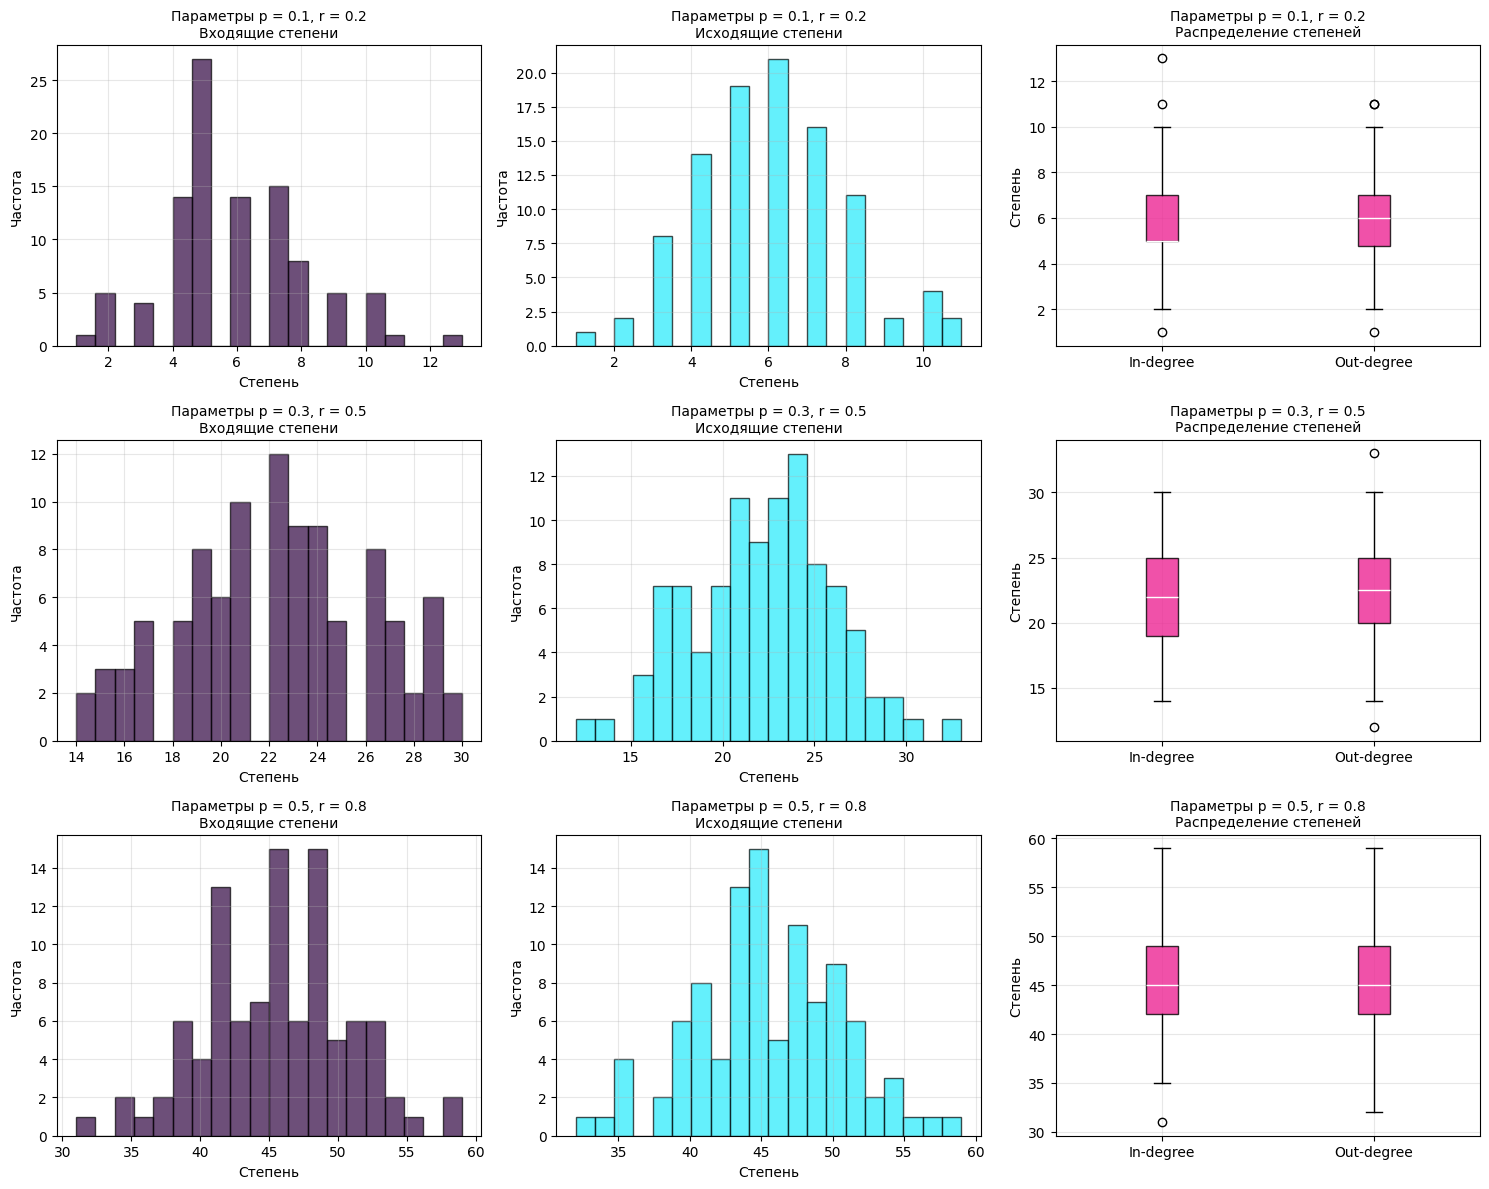

In [43]:
fig, axes = plt.subplots(len(param_pairs), 3, figsize=(15, 12))

for idx, (p, r) in enumerate(param_pairs):
    G = graphs[idx]
    
    # Распределение степеней
    in_degrees = [d for n, d in G.in_degree()]
    out_degrees = [d for n, d in G.out_degree()]
    
    # Гистограмма входящих степеней
    axes[idx, 0].hist(in_degrees, bins=20, edgecolor='black', alpha=0.7, color='#2f0440')
    axes[idx, 0].set_title(f'Параметры p = {p}, r = {r}\nВходящие степени', fontsize=10)
    axes[idx, 0].set_xlabel('Степень')
    axes[idx, 0].set_ylabel('Частота')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Гистограмма исходящих степеней
    axes[idx, 1].hist(out_degrees, bins=20, edgecolor='black', alpha=0.7, color='#23eafc')
    axes[idx, 1].set_title(f'Параметры p = {p}, r = {r}\nИсходящие степени', fontsize=10)
    axes[idx, 1].set_xlabel('Степень')
    axes[idx, 1].set_ylabel('Частота')
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Ящик с усами распределения степеней
    axes[idx, 2].boxplot([in_degrees, out_degrees], 
                         tick_labels=['In-degree', 'Out-degree'], 
                         patch_artist=True,
                         boxprops=dict(facecolor='#ed2694', alpha=0.8),
                         medianprops=dict(color='white'),
                         whiskerprops=dict(color='black'),
                         capprops=dict(color='black'))
    axes[idx, 2].set_title(f'Параметры p = {p}, r = {r}\nРаспределение степеней', fontsize=10)
    axes[idx, 2].set_ylabel('Степень')
    axes[idx, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Выводы по распределению степеней:
Изменение параметров p и r приводит к ожидаемым изменениям распределений степеней и транзитивности, что подтверждает корректность модели генерации сети.

### 3) Зависимость от  𝑟  (3 балла)
Пусть  𝑝=𝑐𝑜𝑛𝑠𝑡 , а параметр  𝑟  меняется в интервале  [0,1] . Постройте зависимость транзитивности (или средний путь) сети от параметра  𝑟 . Объясните результаты

In [44]:
p_fixed = 0.3
n_nodes = 200  # увеличиваем размер графа для более стабильных результатов

# Значения r от 0 до 1
r_values = np.linspace(0, 1, 21)

# Создаем списки для хранения результатов
transitivity_values = []
avg_path_lengths = []
density_values = []
reciprocity_values = []

print(f"\nПараметры p = {p_fixed}, n = {n_nodes}")

for i, r in enumerate(r_values):
    # Генерируем граф
    G = generate_directed_erdos_renyi(n=n_nodes, p=p_fixed, r=r, seed=i*50)
    
    # Преобразуем в неориентированный граф для вычисления транзитивности
    G_undirected = G.to_undirected()
    
    # Вычисляем метрики
    try:
        transitivity = nx.transitivity(G_undirected)
    except:
        transitivity = 0
    
    try:
        # Средняя длина пути (только для связных компонент)
        if nx.is_connected(G_undirected):
            avg_path = nx.average_shortest_path_length(G_undirected)
        else:
            # Для несвязных графов вычисляем среднее по компонентам
            components = list(nx.connected_components(G_undirected))
            path_lengths = []
            for comp in components:
                if len(comp) > 1:
                    subgraph = G_undirected.subgraph(comp)
                    path_lengths.append(nx.average_shortest_path_length(subgraph))
            avg_path = np.mean(path_lengths) if path_lengths else 0
    except:
        avg_path = 0
    
    # Добавляем еще другие метрики
    density = nx.density(G)
    actual_r = calculate_reciprocity(G)
    
    # Сохраняем результаты
    transitivity_values.append(transitivity)
    avg_path_lengths.append(avg_path)
    density_values.append(density)
    reciprocity_values.append(actual_r)
    
    if i % 4 == 0:
        print(f"r = {r:.2f}: транзитивность = {transitivity:.4f}, средний путь = {avg_path:.3f}")


Параметры p = 0.3, n = 200
r = 0.00: транзитивность = 0.2999, средний путь = 1.699
r = 0.20: транзитивность = 0.3046, средний путь = 1.696
r = 0.40: транзитивность = 0.2981, средний путь = 1.702
r = 0.60: транзитивность = 0.3069, средний путь = 1.693
r = 0.80: транзитивность = 0.3044, средний путь = 1.698
r = 1.00: транзитивность = 0.2977, средний путь = 1.702


Визуализируем зависимость метрик от значений параметра r 

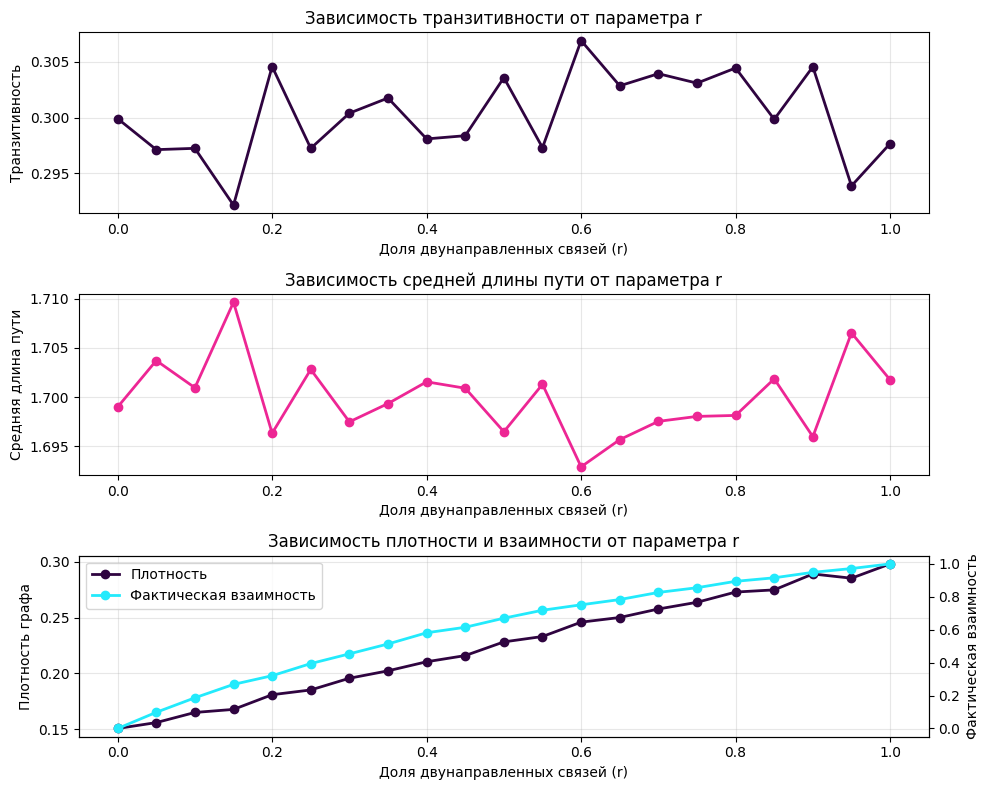

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
colors = ['#2f0440', '#23eafc', '#ed2694', '#23eafc']

# Транзитивность
axes[0].plot(r_values, transitivity_values, 'o-', color=colors[0], linewidth=2, markersize=6)
axes[0].set_xlabel('Доля двунаправленных связей (r)', fontsize=10)
axes[0].set_ylabel('Транзитивность', fontsize=10)
axes[0].set_title('Зависимость транзитивности от параметра r', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-0.05, 1.05])

# Средняя длина пути
axes[1].plot(r_values, avg_path_lengths, 'o-', color=colors[2], linewidth=2, markersize=6)
axes[1].set_xlabel('Доля двунаправленных связей (r)', fontsize=10)
axes[1].set_ylabel('Средняя длина пути', fontsize=10)
axes[1].set_title('Зависимость средней длины пути от параметра r', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-0.05, 1.05])

# Плотность и фактическая взаимность
ax3_secondary = axes[2].twinx()
line1 = axes[2].plot(r_values, density_values, 'o-', color=colors[0], 
                     linewidth=2, markersize=6, label='Плотность')
line2 = ax3_secondary.plot(r_values, reciprocity_values, 'o-', color=colors[3], 
                          linewidth=2, markersize=6, label='Фактическая взаимность')

axes[2].set_xlabel('Доля двунаправленных связей (r)', fontsize=10)
axes[2].set_ylabel('Плотность графа', fontsize=10, color='black')  
ax3_secondary.set_ylabel('Фактическая взаимность', fontsize=10, color='black')  
axes[2].set_title('Зависимость плотности и взаимности от параметра r', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([-0.05, 1.05])

lines = line1 + line2
labels = [l.get_label() for l in lines]
axes[2].legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

### Выводы из расчета значений метрик в зависимости от параметра r:
Доля двунаправленных связей существенно влияет на структурные свойства сети: увеличение r обычно приводит к росту транзитивности и сокращению среднего пути, поскольку двунаправленные связи способствуют образованию треугольников, дополнительных циклов и альтернативных маршрутов.

- при `r = 0` - все связи однонаправленные, граф похож на классический направленный ER-граф
- при `r = 1` - все связи двунаправленные, граф эквивалентен неориентированному ER-графу
- при `0 < r < 1` - смешанная структура с заданной долей взаимных связей

In [46]:
max_trans_idx = np.argmax(transitivity_values)
min_path_idx = np.argmin(avg_path_lengths)

print(f"Максимальная транзитивность - {transitivity_values[max_trans_idx]:.4f} при r = {r_values[max_trans_idx]:.2f}")
print(f"Минимальная транзитивность - {min(transitivity_values):.4f} при r = {r_values[np.argmin(transitivity_values)]:.2f}")

print(f"\nМинимальная длина пути - {avg_path_lengths[min_path_idx]:.3f} при r = {r_values[min_path_idx]:.2f}")
print(f"Максимальная длина пути - {max(avg_path_lengths):.3f} при r = {r_values[np.argmax(avg_path_lengths)]:.2f}")


Максимальная транзитивность - 0.3069 при r = 0.60
Минимальная транзитивность - 0.2922 при r = 0.15

Минимальная длина пути - 1.693 при r = 0.60
Максимальная длина пути - 1.710 при r = 0.15


In [47]:
if transitivity_values[-1] > transitivity_values[0]:
    print("Транзитивность возрастает с увеличением r")
    print("Больше двунаправленных связей → больше треугольников → выше кластеризация")
else:
    print("Транзитивность убывает с увеличением r")
    print("Двунаправленные связи распределяются равномерно, не образуя кластеров")

if avg_path_lengths[-1] < avg_path_lengths[0]:
    print("\nСредняя длина пути убывает с увеличением r")
    print("Двунаправленные связи создают более плотную локальную структуру, что уменьшает расстояние между узлами")
else:
    print("\nСредняя длина пути возрастает с увеличением r")
    print("Двунаправленные связи могут создавать локальные кластеры, но уменьшают количество связей между кластерами")
    

Транзитивность убывает с увеличением r
Двунаправленные связи распределяются равномерно, не образуя кластеров

Средняя длина пути возрастает с увеличением r
Двунаправленные связи могут создавать локальные кластеры, но уменьшают количество связей между кластерами
